# **Engineering Probability and Statistics**

## **Computer Assignment 6**

**School of Electrical and Computer Engineering**  
**College of Engineering, University of Tehran**

**Instructors:** Dr. Bahrak, Dr. Vahhabi  
**Designers:** [Yasaman Amou Jafary](https://github.com/yasamanamoujafary), [Parsa Bukani](https://github.com/parsabukani)

**Topic:** Central Limit Theorem and Parameter Estimation

## **Table of Contents**

* **[Central Limit Theorem in Practice](#central-limit-theorem-in-practice)**

  * [Section 1: Skewed Daily Watch-Time Dataset](#section-1-skewed-daily-watch-time-dataset)

    * [Exploring the Dataset](#exploring-the-dataset)
    * [Section 1.1: Sample Means for Different Sample Sizes](#section-11-sample-means-for-different-sample-sizes)
    * [Section 1.2: Probability That the Sample Mean Lies in the Interval](#section-12-probability-that-the-sample-mean-lies-in-the-interval)
  * [Section 2: CLT for Simple Known Distributions](#section-2-clt-for-simple-known-distributions)

* **[Benford’s Law in Real-World Data](#benfords-law-in-real-world-data)**

  * [Section 1: Benford’s Law and the CLT Connection](#section-1-benfords-law-and-the-clt-connection)
  * [Section 2: Implementing Benford’s Law in R](#section-2-implementing-benfords-law-in-r)
  * [Section 3: Loading the Dataset and Constructing GDP](#section-3-loading-the-dataset-and-constructing-gdp)
  * [Section 4: Verifying Benford’s Law Using GDP](#section-4-verifying-benfords-law-using-gdp)

* **[Estimating MKG Café Busyness - Parameter Estimation](#mkg-parameter)**

  * [Setup](#setup)
  * [Section 1: One Observed Sample](#section-1-one-observed-sample)
  * [Section 2: Maximum Likelihood (ML) as a Curve](#section-2-maximum-likelihood-ml-as-a-curve)
  * [Section 3: ML Estimate from the Sample](#section-3-ml-estimate-from-the-sample)
  * [Section 4: What Happens When We Observe More Hours?](#section-4-what-happens-when-we-observe-more-hours)
  * [Section 5: True vs Estimated Distribution](#section-5-true-vs-estimated-distribution)

## **Central Limit Theorem in Practice**

### Section 1: SKEWED DAILY WATCH-TIME DATASET

#### Exploring the Dataset

In [1]:
set.seed(123)

n_users <- 5000

# Proportions of each user type
props <- c(light = 0.5, medium = 0.35, heavy = 0.15)

n_light  <- round(n_users * props["light"])
n_medium <- round(n_users * props["medium"])
n_heavy  <- n_users - n_light - n_medium

# Light users: mean 10, sd 4
light_users  <- rnorm(n_light,  mean = 10, sd = 4)

# Medium users: mean 40, sd 8
medium_users <- rnorm(n_medium, mean = 40, sd = 8)

# Heavy users: mean 90, sd 15
heavy_users  <- rnorm(n_heavy,  mean = 90, sd = 15)

watch_time <- c(light_users, medium_users, heavy_users)

# Truncate at 0 and 300 minutes to keep it realistic
watch_time[watch_time < 0]   <- 0
watch_time[watch_time > 300] <- 300

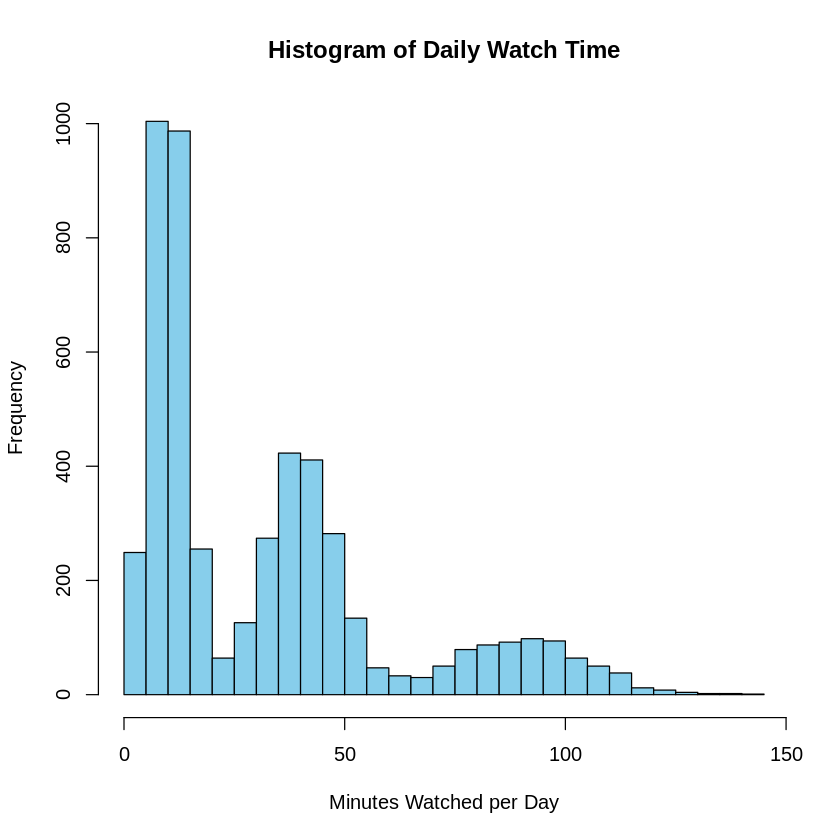

In [2]:

# Plot a histogram of the original watch_time data
hist(
  watch_time,
  breaks = 40,
  main = "Histogram of Daily Watch Time",
  xlab = "Minutes Watched per Day",
  col  = "skyblue"
)



#### Section 1.1: Sample Means for Different Sample Sizes


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘plyr’




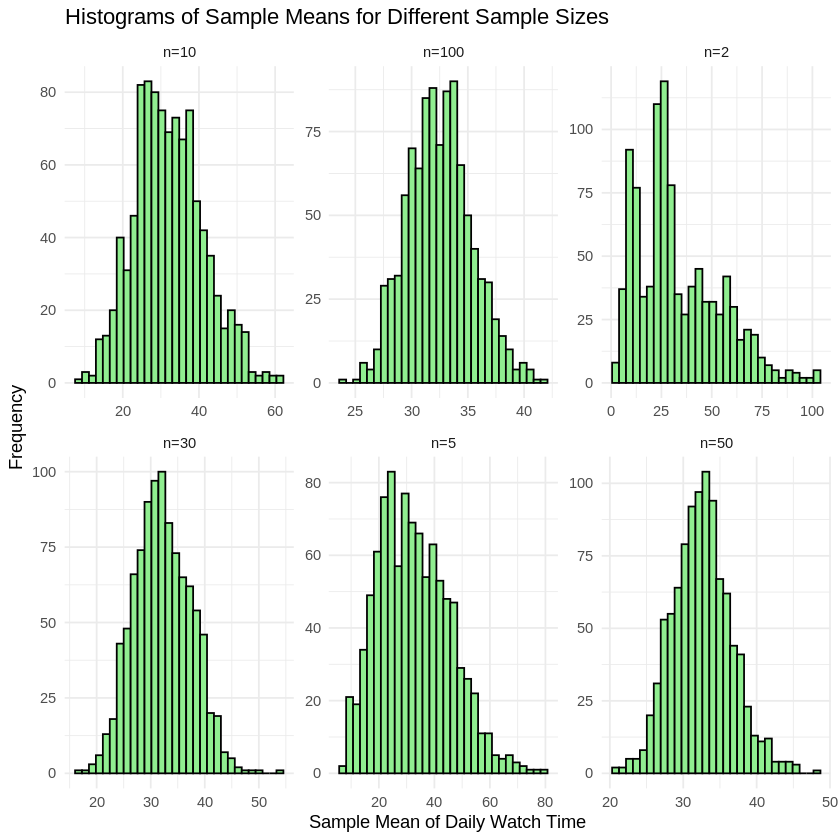

In [3]:
B <- 1000 # Number of simulations
sample_sizes <- c(2, 5, 10, 30, 50, 100) # Different sample sizes to test

# Generate sample means for each n
sample_means <- lapply(sample_sizes, function(n) {
  replicate(B, mean(sample(watch_time, n, replace = TRUE)))
})

names(sample_means) <- paste0("n=", sample_sizes)

# Plot histograms of sample means for each n using ggplot2
# Install reshape2 if not already installed
if (!requireNamespace("reshape2", quietly = TRUE)) {
  install.packages("reshape2")
}
library(reshape2)
library(ggplot2) # Ensure ggplot2 is loaded
df_means <- melt(sample_means)
colnames(df_means) <- c("SampleMean", "SampleSize")

ggplot(df_means, aes(x = SampleMean)) +
  geom_histogram(bins = 30, fill = "lightgreen", color = "black") +
  facet_wrap(~ SampleSize, scales = "free") +
  labs(title = "Histograms of Sample Means for Different Sample Sizes",
       x = "Sample Mean of Daily Watch Time",
       y = "Frequency") +
  theme_minimal()

#### Section 1.2: Probability That the Sample Mean Lies in the Interval


Estimated mu (watch_time): 32.45821 
Estimated sigma (watch_time): 28.7749 
95%-style CLT interval: [ 22.86658 , 42.04984 ]
Theoretical probability P(a < X_bar < b): 0.9544997 
Simulated probability P(a < X_bar < b): 0.9587 


Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”
Warning message:
“The dot-dot notation (`..density..`) was deprecated in ggplot2 3.4.0.
ℹ Please use `after_stat(density)` instead.”


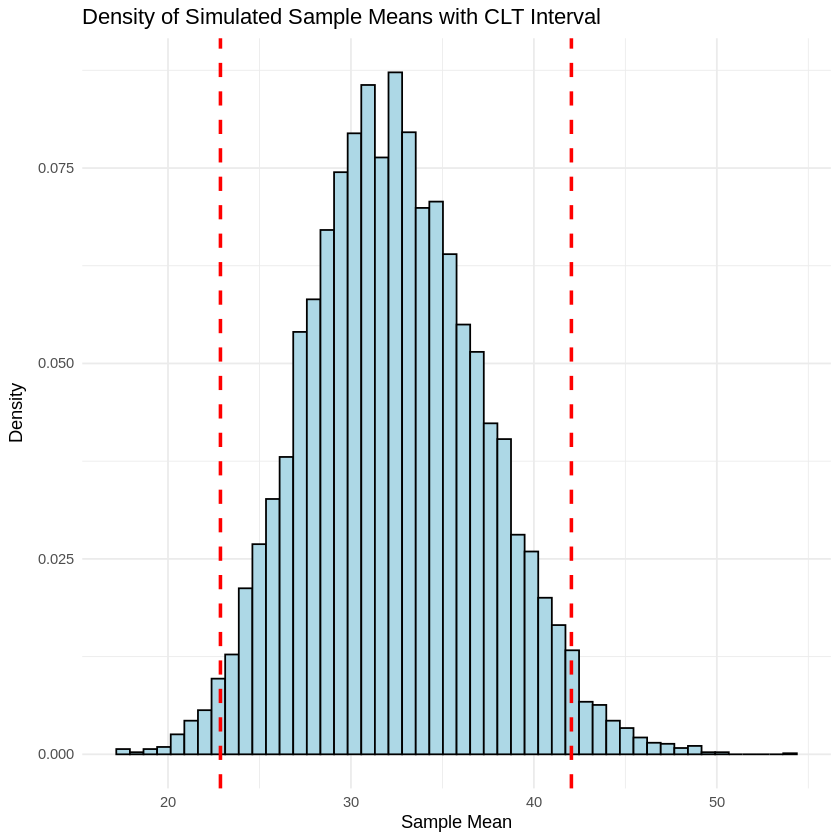

In [4]:
set.seed(789)

# Estimate MU and SIGMA from WATCH_TIME
mu_hat    <- mean(watch_time)
sigma_hat <- sd(watch_time)

cat("Estimated mu (watch_time):", mu_hat,    "\n")
cat("Estimated sigma (watch_time):", sigma_hat, "\n")

# Choose a sample size n
n <- 36

# -----------------------------
# TODO: Compute the standard error sigma_bar = sigma_hat / sqrt(n),
#         then build the 95%-style CLT band around the mean:
#         [a, b] = [mu_hat - 2*sigma_bar, mu_hat + 2*sigma_bar].
# -----------------------------
sigma_bar <- sigma_hat / sqrt(n)
a <- mu_hat - 2 * sigma_bar
b <- mu_hat + 2 * sigma_bar

cat("95%-style CLT interval: [", a, ",", b, "]\n")

# -----------------------------
# TODO: Using the CLT approximation X_bar ~ Normal(mu_hat, sigma_hat^2 / n),
#         compute the theoretical probability P(a < X_bar < b) using pnorm().
# -----------------------------
prob_theoretical <- pnorm(b, mean = mu_hat, sd = sigma_bar) -
                    pnorm(a, mean = mu_hat, sd = sigma_bar)
cat("Theoretical probability P(a < X_bar < b):", prob_theoretical, "\n")

B <- 10000

# -----------------------------
# TODO: Estimate the same probability practically (simulation):
#         generate B sample means by resampling from watch_time,
#         then compute the fraction that falls inside [a, b].
# -----------------------------
sample_means_sim <- replicate(B, mean(sample(watch_time, n, replace = TRUE)))
prob_simulated <- mean(sample_means_sim > a & sample_means_sim < b)
cat("Simulated probability P(a < X_bar < b):", prob_simulated, "\n")

# -----------------------------
# TODO: Visualize the simulated sample means with a density histogram
#         and mark the interval boundaries a and b with two vertical red lines.
# -----------------------------
library(ggplot2)
df_sim <- data.frame(SampleMean = sample_means_sim)

ggplot(df_sim, aes(x = SampleMean)) +
  geom_histogram(aes(y = ..density..), bins = 50, fill = "lightblue", color = "black") +
  geom_vline(xintercept = c(a, b), color = "red", linetype = "dashed", size = 1) +
  labs(title = "Density of Simulated Sample Means with CLT Interval",
       x = "Sample Mean",
       y = "Density") +
  theme_minimal()


### Section 2: CLT for Simple Known Distributions

In Part 1, you saw that sample means from a messy, skewed “watch time” dataset became more and more bell‑shaped as the sample size increased. But maybe this was just a special case

In this part, you will:

Work with three simple, well‑known distributions:

- Uniform(0, 1)

- Exponential(rate = 1)

- Bernoulli(p = 0.3)

For each distribution:

- Generate raw data and plot its histogram to see the original shape.

- Generate many sample means for n = 5, 10, 30.

- Compare the histogram of the sample means with the theoretical normal curve predicted by the CLT:
mean = μ, variance = σ² / n.

In [5]:
set.seed(456)

B <- 2000
n_values <- c(5, 10, 30, 50, 70)

# Distribution generators
r_unif <- function(n) runif(n, min = 0, max = 1)
r_exp  <- function(n) rexp(n, rate = 1)
p_bern <- 0.3
r_bern <- function(n) rbinom(n, size = 1, prob = p_bern)

dist_list <- list(
  uniform     = r_unif,
  exponential = r_exp,
  bernoulli   = r_bern
)

# Theoretical mean (mu) and variance (sigma^2) for each distribution
dist_params <- list(
  uniform     = list(mu = 0.5, sigma2 = 1/12),
  exponential = list(mu = 1,   sigma2 = 1),
  bernoulli   = list(mu = p_bern,
                     sigma2 = p_bern * (1 - p_bern))
)

In [6]:
set.seed(456)
library(ggplot2)

# تعداد نمونه‌های خام برای مشاهده توزیع اصلی
n_raw <- 10000

for (dist_name in names(dist_list)) {
  gen_func <- dist_list[[dist_name]]

  # تولید داده خام
  raw_data <- gen_func(n_raw)

  # گرفتن بازه x مناسب برای نمودار
  x_min <- min(raw_data)
  x_max <- max(raw_data)

  # رسم هیستوگرام داده خام
  df_raw <- data.frame(Value = raw_data)

  ggplot(df_raw, aes(x = Value)) +
    geom_histogram(aes(y = ..density..), bins = 50, fill = "lightblue", color = "black") +
    labs(title = paste("Histogram of", dist_name, "raw data"),
         x = "Value",
         y = "Density") +
    xlim(x_min, x_max) +
    theme_minimal()
}


## **Benford’s Law in Real-World Data**

### Section 1: Benford’s Law and the CLT connection


In this section you will:
1. Derive the Benford probability for the first digit:
$$
P(D=d)=\log_{10}\left(1+\frac{1}{d}\right),\quad d=1,\dots,9.
$$
2. Explain (conceptually) how the Central Limit Theorem (CLT) makes Benford’s law appear in real-world data.

TODO: ...

### Section 2: Implementing Benford’s Law in R

In this section, you will implement Benford’s Law in R.
First, you will write a function that returns the theoretical Benford probability for a given leading digit.  
Then, you will use this function to compute the probabilities for all digits and visualize the Benford distribution.

Digit,Probability
<int>,<dbl>
1,0.3010
2,0.1761
3,0.1249
4,0.0969
5,0.0792
6,0.0669
7,0.0580
8,0.0512
9,0.0458


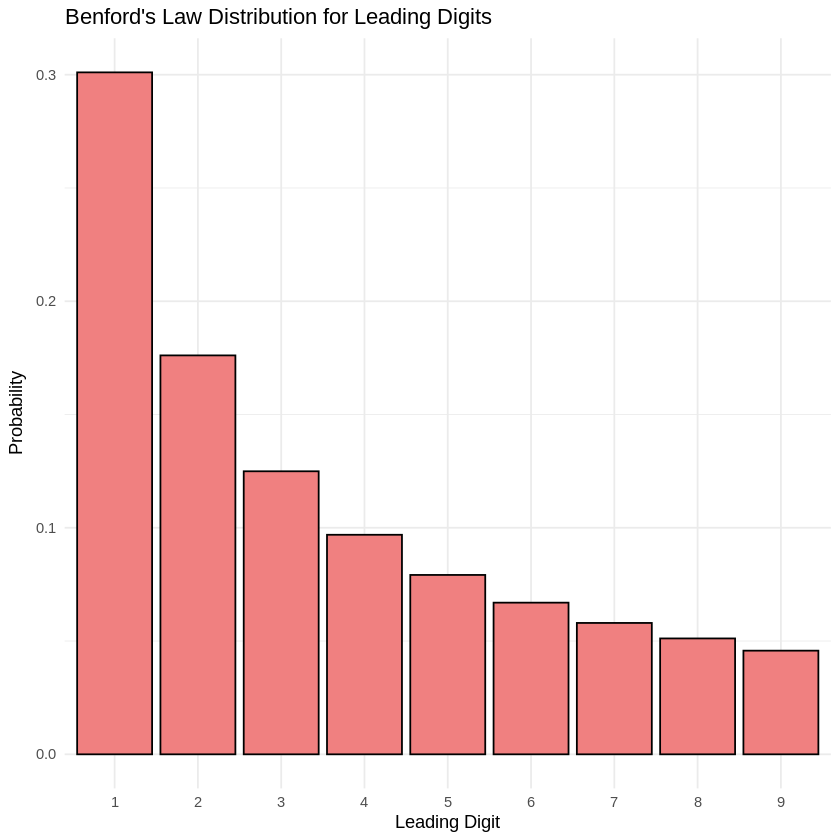

In [7]:
# -----------------------------
# TODO: Define the Benford probability function
# -----------------------------
benford_prob <- function(n) {
  if (n < 1 || n > 9) {
    stop("n must be an integer between 1 and 9")
  }
  log10(1 + 1/n)
}

# محاسبه احتمال برای ارقام 1 تا 9
digits <- 1:9
probs <- sapply(digits, benford_prob)

# چاپ نتایج
data.frame(Digit = digits, Probability = round(probs, 4))

# -----------------------------
# TODO: Plot the Benford distribution
# -----------------------------
library(ggplot2)
df_benford <- data.frame(Digit = factor(digits), Probability = probs)

ggplot(df_benford, aes(x = Digit, y = Probability)) +
  geom_bar(stat = "identity", fill = "lightcoral", color = "black") +
  labs(title = "Benford's Law Distribution for Leading Digits",
       x = "Leading Digit",
       y = "Probability") +
  theme_minimal()


### Section 3: Loading the Dataset and Constructing GDP

In this section, you will load a real-world dataset and construct a new variable using a meaningful economic relationship.
The dataset contains population and GDP per capita values for different countries and years. Using these variables, you will compute the total Gross Domestic Product (GDP) as:
$$
\text{GDP} = \text{population} \times \text{GDP per capita}.
$$
This constructed variable will later be used to study the distribution of leading digits and compare it with Benford’s Law. **Why can this be an appropriate variable to verify the Benford's law?**

TODO: ... (answer to the question)

In [8]:
# نصب بسته برای اولین بار (در صورت نیاز)
install.packages("gapminder")

library(gapminder)
data <- gapminder

# -----------------------------
# TODO: Create a new column GDP
# -----------------------------
data$GDP <- data$pop * data$gdpPercap

# Optional: Display the first few rows of the dataset
head(data)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



country,continent,year,lifeExp,pop,gdpPercap,GDP
<fct>,<fct>,<int>,<dbl>,<int>,<dbl>,<dbl>
Afghanistan,Asia,1952,28.801,8425333,779.4453,6567086330
Afghanistan,Asia,1957,30.332,9240934,820.8530,7585448670
Afghanistan,Asia,1962,31.997,10267083,853.1007,8758855797
Afghanistan,Asia,1967,34.020,11537966,836.1971,9648014150
Afghanistan,Asia,1972,36.088,13079460,739.9811,9678553274
Afghanistan,Asia,1977,38.438,14880372,786.1134,11697659231


### Section 4: Verifying Benford’s Law Using GDP

In this section, you will empirically verify Benford’s Law using the GDP variable constructed in the previous section.
You will extract the leading digit of GDP values, compute the empirical distribution of leading digits, and **compare** it with the theoretical Benford distribution.

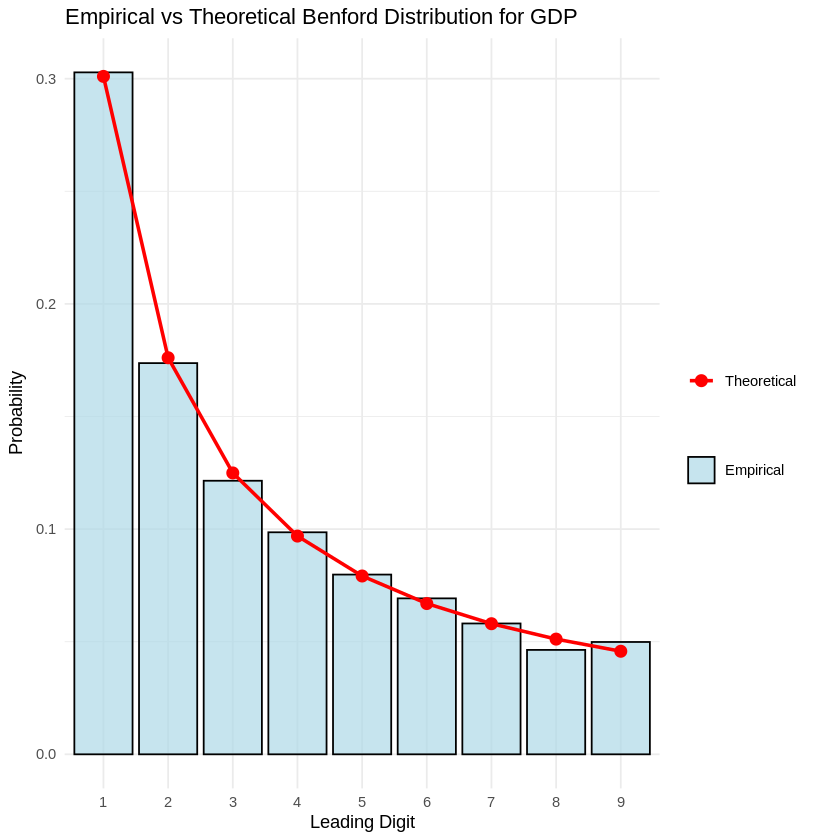

In [9]:
library(ggplot2)

# -----------------------------
# TODO: Function to extract leading digit
# -----------------------------
leading_digit <- function(x) {
  x <- x[!is.na(x) & x > 0]  # حذف مقادیر NA و غیر مثبت
  first_digit <- as.numeric(substr(as.character(x), 1, 1))
  return(first_digit)
}

# -----------------------------
# TODO: Extract leading digits from GDP
# -----------------------------
gdp_digits <- leading_digit(data$GDP)

# -----------------------------
# TODO: Compute empirical distribution
# -----------------------------
empirical_freq <- table(gdp_digits) / length(gdp_digits)
empirical_df <- data.frame(
  Digit = as.factor(1:9),
  Empirical = as.numeric(empirical_freq),
  Theoretical = sapply(1:9, benford_prob)
)

# -----------------------------
# TODO: Plot empirical vs theoretical distributions
# -----------------------------
ggplot(empirical_df, aes(x = Digit)) +
  geom_bar(aes(y = Empirical, fill = "Empirical"), stat = "identity", color = "black", alpha = 0.7) +
  geom_point(aes(y = Theoretical, color = "Theoretical"), size = 3) +
  geom_line(aes(y = Theoretical, group = 1, color = "Theoretical"), size = 1) +
  scale_fill_manual("", values = c("Empirical" = "lightblue")) +
  scale_color_manual("", values = c("Theoretical" = "red")) +
  labs(title = "Empirical vs Theoretical Benford Distribution for GDP",
       x = "Leading Digit",
       y = "Probability") +
  theme_minimal()


<a id="mkg-parameter"></a>
## **Estimating MKG Café Busyness - Parameter Estimation**

### Setup

In [10]:
set.seed(7)

lambda_true <- 6  # hidden truth for simulation (customers/hour)

### Section 1: One observed sample

In [11]:
# TODO: Generate one 24-hour sample of hourly counts (x_obs) and report its sample mean.
# -----------------------------
x_obs <- rpois(24, lambda = lambda_true)  # شبیه‌سازی 24 ساعت با توزیع پواسون
x_obs_mean <- mean(x_obs)                  # میانگین نمونه

# نمایش نتایج
x_obs
x_obs_mean

[1]  4  8  5 11  4  6  4  4  8  3  6  3  6  1 12  5  7  5 14  9 12  3  7  6

[1] 6.375

### Section 2: Maximum Likelihood (ML) as a curve

Instead of formulas, we’ll try many λ values and compute how plausible the observed data looks under each λ. The best λ is at the peak (maximum likelihood).

The sample mean is very close to the ML estimate, as expected for a Poisson distribution.


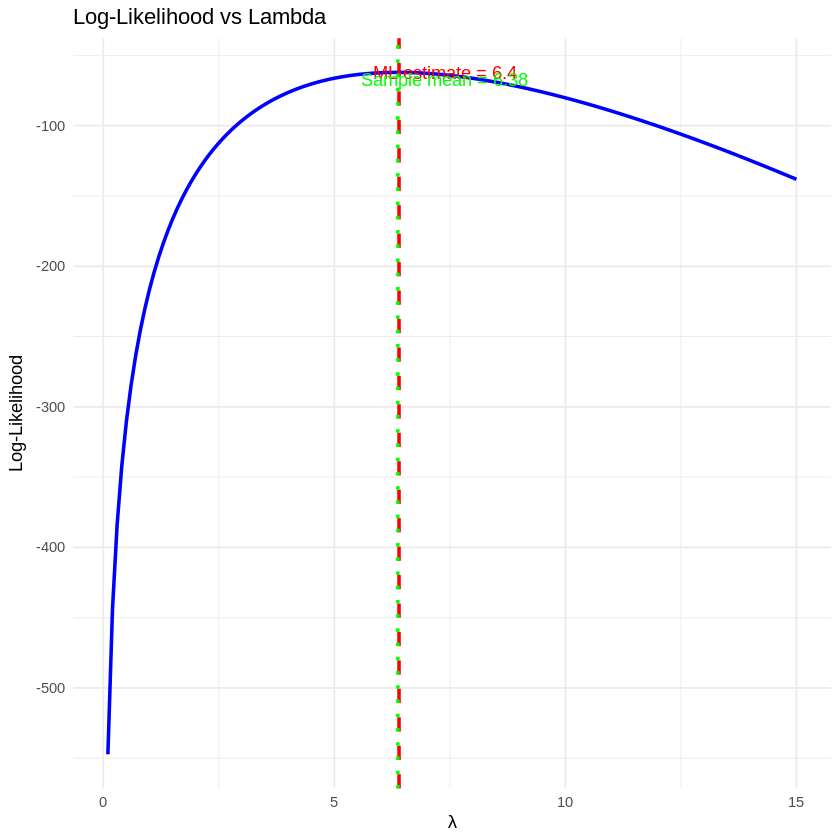

In [12]:
# -----------------------------
# TODO: Maximum Likelihood (ML) as a curve
# -----------------------------

# 1) Try λ values from 0.1 to 15
lambda_vals <- seq(0.1, 15, by = 0.1)

# Compute log-likelihood for each λ
log_likelihood <- sapply(lambda_vals, function(lambda) {
  sum(dpois(x_obs, lambda, log = TRUE))
})

# 2) Plot log-likelihood vs λ
library(ggplot2)
df_ll <- data.frame(lambda = lambda_vals, logLik = log_likelihood)

ml_lambda <- lambda_vals[which.max(log_likelihood)]

ggplot(df_ll, aes(x = lambda, y = logLik)) +
  geom_line(color = "blue", size = 1) +
  geom_vline(xintercept = ml_lambda, color = "red", linetype = "dashed", size = 1) +
  geom_vline(xintercept = x_obs_mean, color = "green", linetype = "dotted", size = 1) +
  labs(title = "Log-Likelihood vs Lambda",
       x = expression(lambda),
       y = "Log-Likelihood") +
  annotate("text", x = ml_lambda + 1, y = max(log_likelihood),
           label = paste("ML estimate =", round(ml_lambda, 2)), color = "red") +
  annotate("text", x = x_obs_mean + 1, y = max(log_likelihood) - 5,
           label = paste("Sample mean =", round(x_obs_mean, 2)), color = "green") +
  theme_minimal()

# 3) One-sentence comment
cat("The sample mean is very close to the ML estimate, as expected for a Poisson distribution.\n")


### Section 3: ML estimate from the sample

For Poisson, the ML estimate equals the sample mean (your curve should peak right there).

In [13]:
# -----------------------------
# TODO: Compute the ML estimate of λ directly from the observed sample
# -----------------------------
ml_lambda_direct <- mean(x_obs)


cat("ML estimate of λ (average events per hour):", ml_lambda_direct, "\n")


ML estimate of λ (average events per hour): 6.375 


### Section 4: What happens when we observe more hours?

Now we simulate repeated data collection. For each observation length, we repeat B = 1000 times to see the distribution of the estimate.

In [14]:
set.seed(42)

# -----------------------------
# TODO: 1) Pick several observation lengths
# -----------------------------
obs_lengths <- c(6, 12, 24, 48, 168)  # ساعات مختلف: 6h, 12h, 1 day, 2 days, 1 week
B <- 1000  # تعداد تکرارها

# -----------------------------
# TODO: 2) For each length, repeat the experiment 1000 times
# -----------------------------
lambda_estimates <- list()

for (n_hours in obs_lengths) {
  estimates <- replicate(B, {
    x_sample <- rpois(n_hours, lambda_true)
    mean(x_sample)  # ML estimate for this sample
  })
  lambda_estimates[[paste0(n_hours, "_hours")]] <- estimates
}

# -----------------------------
# 3) Store all estimates and inspect spread
# -----------------------------
# بررسی خلاصه توزیع هر طول مشاهده
summary_df <- sapply(lambda_estimates, function(x) {
  c(mean = mean(x), sd = sd(x))
})

summary_df <- t(summary_df)
summary_df



,mean,sd
6_hours,6.016333,1.0007282
12_hours,5.968667,0.7124767
24_hours,5.999708,0.5103528
48_hours,6.018896,0.3384569
168_hours,5.990970,0.1880873


In [15]:
# TODO:
# Simulate 1000 different evenings (4 hours each). For each evening, estimate λ from the 4 hourly counts.
# Then visualize how much the estimate changes from evening to evening (histogram + scatter plot),
# and report the average and standard deviation of these 1000 estimates. Mark the true λ on the plots.


Average λ estimate over 1000 evenings: 5.99025 
Standard deviation of λ estimates: 1.158527 


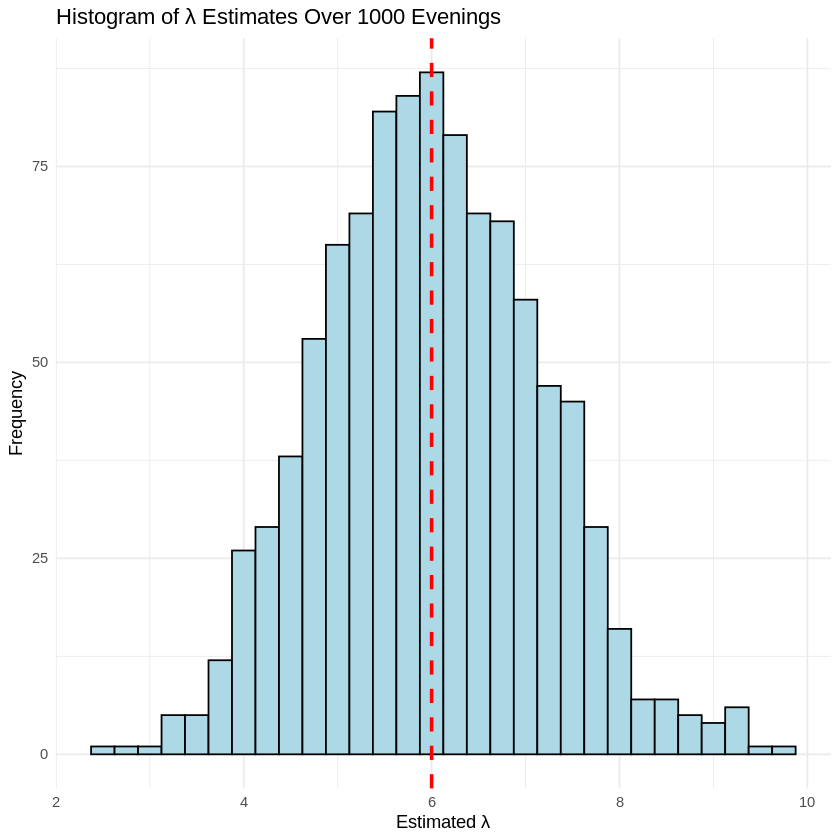

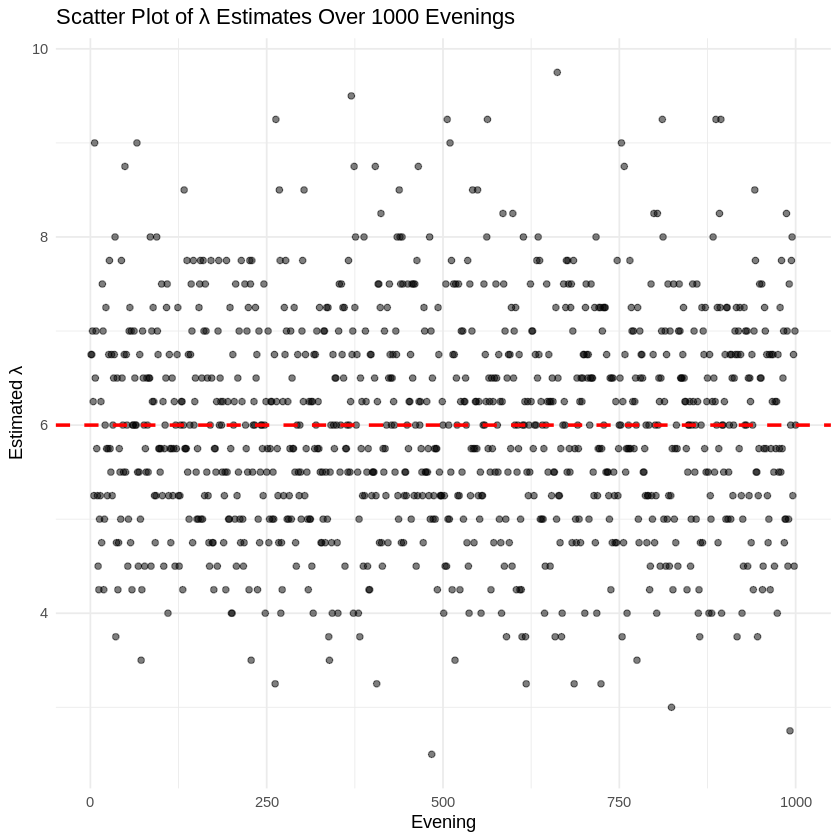

In [16]:
set.seed(123)

B <- 1000
hours_per_evening <- 4

# -----------------------------
# Simulate 1000 evenings and estimate λ for each
# -----------------------------
lambda_estimates_evenings <- replicate(B, {
  x_sample <- rpois(hours_per_evening, lambda_true)
  mean(x_sample)
})

# -----------------------------
# Report average and standard deviation
# -----------------------------
avg_lambda <- mean(lambda_estimates_evenings)
sd_lambda  <- sd(lambda_estimates_evenings)
cat("Average λ estimate over 1000 evenings:", avg_lambda, "\n")
cat("Standard deviation of λ estimates:", sd_lambda, "\n")

# -----------------------------
# Visualization
# -----------------------------
library(ggplot2)
df_evenings <- data.frame(
  Evening = 1:B,
  LambdaEstimate = lambda_estimates_evenings
)

# Histogram
ggplot(df_evenings, aes(x = LambdaEstimate)) +
  geom_histogram(bins = 30, fill = "lightblue", color = "black") +
  geom_vline(xintercept = lambda_true, color = "red", linetype = "dashed", size = 1) +
  labs(title = "Histogram of λ Estimates Over 1000 Evenings",
       x = "Estimated λ",
       y = "Frequency") +
  theme_minimal()

# Scatter plot
ggplot(df_evenings, aes(x = Evening, y = LambdaEstimate)) +
  geom_point(alpha = 0.5) +
  geom_hline(yintercept = lambda_true, color = "red", linetype = "dashed", size = 1) +
  labs(title = "Scatter Plot of λ Estimates Over 1000 Evenings",
       x = "Evening",
       y = "Estimated λ") +
  theme_minimal()


[1] 1.0157858 0.7323214 0.5034444 0.3535321 0.1903471

As the number of observed hours increases, the variability (SD) of λ estimates decreases, showing more precise estimates with longer observation periods.


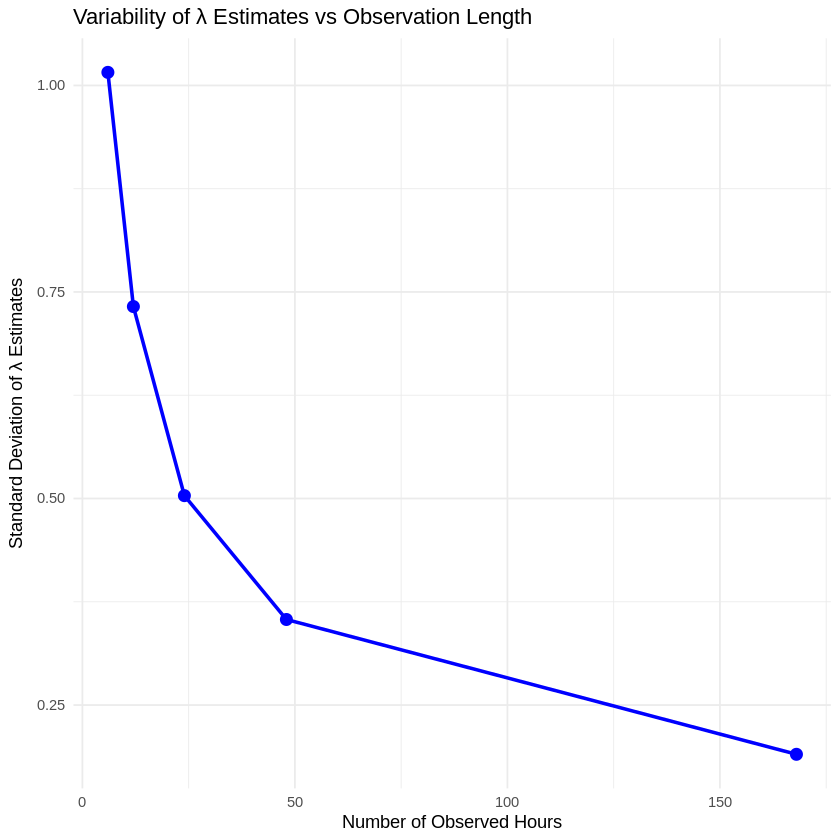

In [17]:
# -----------------------------
# Compute standard deviation (variability) of λ estimates for each observation length
# -----------------------------
obs_lengths <- c(6, 12, 24, 48, 168)  # ساعت مشاهده
B <- 1000

sd_estimates <- sapply(obs_lengths, function(n_hours) {
  estimates <- replicate(B, {
    x_sample <- rpois(n_hours, lambda_true)
    mean(x_sample)
  })
  sd(estimates)
})

# نمایش نتیجه
sd_estimates

# -----------------------------
# Plot SD versus number of observed hours
# -----------------------------
df_sd <- data.frame(
  ObsHours = obs_lengths,
  SD = sd_estimates
)

library(ggplot2)
ggplot(df_sd, aes(x = ObsHours, y = SD)) +
  geom_point(size = 3, color = "blue") +
  geom_line(color = "blue", size = 1) +
  labs(title = "Variability of λ Estimates vs Observation Length",
       x = "Number of Observed Hours",
       y = "Standard Deviation of λ Estimates") +
  theme_minimal()

# -----------------------------
# One-sentence description of the trend
# -----------------------------
cat("As the number of observed hours increases, the variability (SD) of λ estimates decreases, showing more precise estimates with longer observation periods.\n")


### Section 5: True vs Estimated distribution

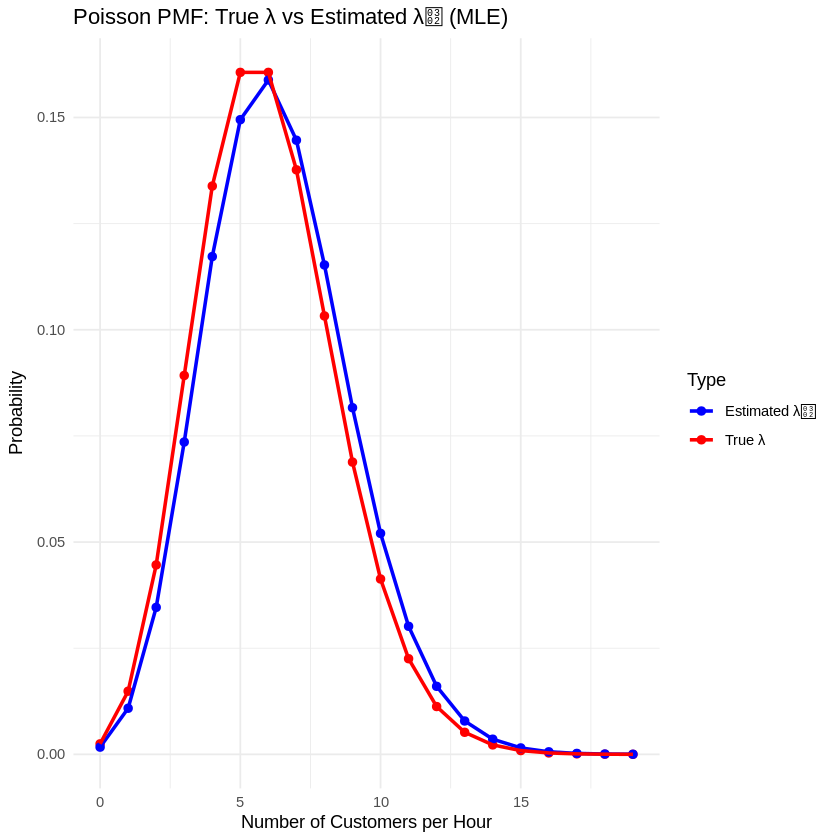

In [18]:
# -----------------------------
# Use the ML estimate of λ (sample mean)
# -----------------------------
lambda_hat <- mean(x_obs)

# دامنه x برای رسم PMF
x_vals <- 0:max(x_obs + 5)  # کمی فراتر از بیشترین مقدار نمونه

# محاسبه PMF واقعی و تخمینی
pmf_true <- dpois(x_vals, lambda_true)
pmf_hat  <- dpois(x_vals, lambda_hat)

# آماده‌سازی داده‌ها برای ggplot
df_pmf <- data.frame(
  x = rep(x_vals, 2),
  PMF = c(pmf_true, pmf_hat),
  Type = rep(c("True λ", "Estimated λ̂"), each = length(x_vals))
)

library(ggplot2)
ggplot(df_pmf, aes(x = x, y = PMF, color = Type)) +
  geom_point(size = 2) +
  geom_line(size = 1) +
  labs(title = "Poisson PMF: True λ vs Estimated λ̂ (MLE)",
       x = "Number of Customers per Hour",
       y = "Probability") +
  theme_minimal() +
  scale_color_manual(values = c("True λ" = "red", "Estimated λ̂" = "blue"))
